In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1
from astropy.visualization import ZScaleInterval
from scipy.optimize import curve_fit

In [2]:
def jinc(x):
    x = np.asarray(x)
    y = np.empty_like(x, dtype=float)
    mask = x != 0
    y[mask] = j1(x[mask]) / x[mask]
    y[~mask] = 0.5
    return y

In [3]:
def intensity_annular_aperture(r_rad_array, wavel, D_aperture, D_obscuration, ampl=1):
    '''
    Calculate the intensity through an aperture with a central obscuration
    Ref. 'E-REP-MPIA-1203 0-1 xx-10-2024', Sec. 4.4

    INPUTS:
    - r_rad_array: 2D array of radial distances from the center (units radians)
    - wavel: wavelength (units meters)
    - D_aperture: aperture diameter (units meters)
    - D_obscuration: obscuration diameter (units meters)

    OUTPUTS:
    - I_r_array: 2D array of intensity on the detector
    '''


    nu_ = np.pi * r_rad_array * D_aperture / wavel # unitless

    eps_ = D_obscuration / D_aperture # unitless
    
    # see Eqn. 43 in 'E-REP-MPIA-1203 0-1 xx-10-2024'
    I_r = (1/(1-eps_**2)**2) * ( (2*jinc(nu_)) - eps_**2 * (2*jinc(nu_*eps_)) ) ** 2

    # normalize to the amplitude
    I_r = ampl * I_r / np.nanmax(I_r)

    return I_r

In [4]:
# Create a 2D array of distances from the center in arcseconds, with each pixel 6 mas
size = 2048 
pixel_scale_mas = 6.0  # milliarcseconds per pixel
pixel_scale_arcsec = pixel_scale_mas / 1000.0  # arcseconds per pixel

y, x = np.indices((size, size))
center = (size // 2, size // 2)
r_pix = np.sqrt((x - center[1])**2 + (y - center[0])**2)
test_array_arcsec_2d = r_pix * pixel_scale_arcsec

# convert to radians
r_rad_2d = test_array_arcsec_2d / ( 3600 * (180/np.pi ) )

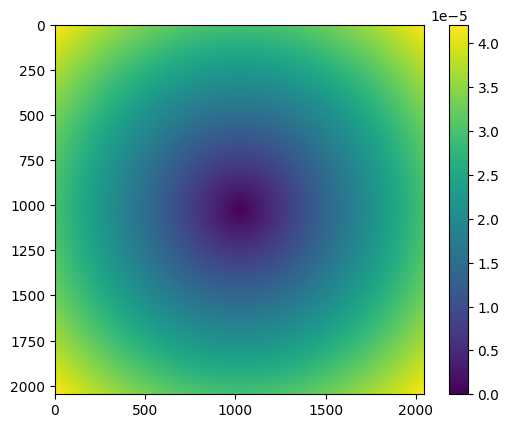

In [5]:
plt.imshow(r_rad_2d)
plt.colorbar()
plt.show()

In [6]:
test_perfect_2d = intensity_annular_aperture(r_rad_array=r_rad_2d, wavel=1e-6, D_aperture=1, D_obscuration=0.5, ampl=1.7)

test_empirical_2d = test_perfect_2d + np.random.normal(0, 0.01, test_perfect_2d.shape)

In [7]:
baseline_shape = test_empirical_2d.shape

In [8]:
# Define a wrapper function for curve_fit
# curve_fit expects: func(x, *params) where x is the independent variable
# and params are the parameters to fit
def model_for_fit(r_rad_1d, D_aperture, D_obscuration, ampl):
    """
    Wrapper function for intensity_annular_aperture to use with curve_fit.
    
    Parameters:
    - r_rad_1d: 1D array of radial distances from the center (units radians); needs to be flat for curve_fit wrapper to accept it
    - D_aperture: aperture diameter (meters)
    - D_obscuration: obscuration diameter (meters)
    - ampl: amplitude
    
    Returns:
    - flattened 1D array of intensity values
    """
    # Reshape the flattened array back to 2D
    r_rad_2d = r_rad_1d.reshape(baseline_shape)
    
    # Calculate intensity using the model function
    # wavel is fixed at 1e-6 meters
    intensity_2d = intensity_annular_aperture(
        r_rad_array=r_rad_2d, 
        wavel=1e-6, 
        D_aperture=D_aperture, 
        D_obscuration=D_obscuration, 
        ampl=ampl
    )
    
    # Flatten back to 1D for curve_fit
    return intensity_2d.flatten()

In [9]:
# Prepare data for fitting

# replace nans with median
test_empirical_2d = np.where(np.isnan(test_empirical_2d), np.nanmedian(test_empirical_2d), test_empirical_2d)
test_perfect_2d = np.where(np.isnan(test_empirical_2d), np.nanmedian(test_empirical_2d), test_empirical_2d)

# mask any nans in the empirical or model data, and apply the same mask to both
'''
mask = ~np.isnan(test_empirical) & ~np.isnan(test_perfect)
test_empirical = np.where(mask, test_empirical, np.nan)
test_perfect = np.where(mask, test_perfect, np.nan)
test_array_rad = np.where(mask, test_array_rad, np.nan)
'''

#print(test_empirical.shape)
#print(test_perfect.shape)
#print(test_array_rad.shape)

'\nmask = ~np.isnan(test_empirical) & ~np.isnan(test_perfect)\ntest_empirical = np.where(mask, test_empirical, np.nan)\ntest_perfect = np.where(mask, test_perfect, np.nan)\ntest_array_rad = np.where(mask, test_array_rad, np.nan)\n'

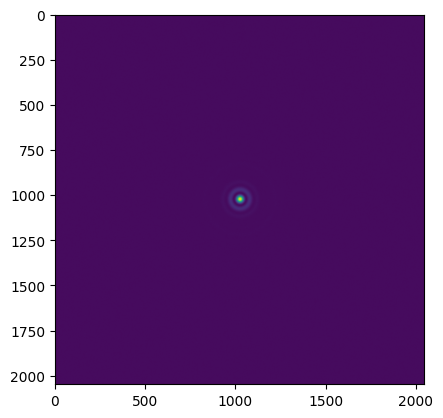

In [10]:
plt.imshow(test_empirical_2d)
plt.show()

In [11]:
# Flatten both arrays first
r_rad_1d_full = r_rad_2d.flatten()
test_empirical_1d_full = test_empirical_2d.flatten()

# Create a SINGLE mask for valid (non-NaN, finite) data points
# Apply the SAME mask to both arrays to keep them aligned
mask = np.isfinite(test_empirical_1d_full) & np.isfinite(r_rad_1d_full)

# Apply the SAME mask to both arrays
r_rad_1d = r_rad_1d_full[mask]
test_empirical_1d = test_empirical_1d_full[mask]

# Store the mask as a global variable for use in model_for_fit
valid_mask = mask.copy()

print(f"Original data points: {len(r_rad_1d_full)}")
print(f"Valid data points after masking: {len(r_rad_1d)}")
print(f"Arrays are aligned: {len(r_rad_1d) == len(test_empirical_1d)}")

Original data points: 4194304
Valid data points after masking: 4194304
Arrays are aligned: True


In [12]:
# Initial parameter guesses
initial_guess = [2., 0.8, 4.]  # [D_aperture, D_obscuration, ampl]

In [13]:
def model_for_fit_fixed(r_rad_1d, D_aperture, D_obscuration, ampl):
    """
    Fixed wrapper function for intensity_annular_aperture to use with curve_fit.
    
    Parameters:
    - r_rad_1d: 1D array of radial distances (masked, only valid points)
    - D_aperture: aperture diameter (meters)
    - D_obscuration: obscuration diameter (meters)
    - ampl: amplitude
    
    Returns:
    - 1D array of intensity values (masked, same length as input)
    """
    # Reconstruct the full 2D array by inserting masked values back into their original positions
    r_rad_2d_full = np.full(baseline_shape, np.nan).flatten()
    r_rad_2d_full[valid_mask] = r_rad_1d
    r_rad_2d = r_rad_2d_full.reshape(baseline_shape)
    
    # Calculate intensity using the model function
    intensity_2d = intensity_annular_aperture(
        r_rad_array=r_rad_2d, 
        wavel=1e-6, 
        D_aperture=D_aperture, 
        D_obscuration=D_obscuration, 
        ampl=ampl
    )
    
    # Flatten and apply the same mask to return only valid points
    intensity_1d_full = intensity_2d.flatten()
    return intensity_1d_full[valid_mask]

In [14]:
# Now perform the fit with the fixed function
popt, pcov = curve_fit(
    model_for_fit_fixed,
    r_rad_1d,
    test_empirical_1d,
    p0=initial_guess,
    method='lm'
)

# Extract best-fit parameters and uncertainties
D_aperture_fit = popt[0]
D_obscuration_fit = popt[1]
ampl_fit = popt[2]

# Calculate parameter uncertainties from covariance matrix
param_errors = np.sqrt(np.diag(pcov))
D_aperture_err = param_errors[0]
D_obscuration_err = param_errors[1]
ampl_err = param_errors[2]

# Print results
print("Best-fit parameters:")
print(f"D_aperture = {D_aperture_fit:.6f} ± {D_aperture_err:.6f} meters")
print(f"D_obscuration = {D_obscuration_fit:.6f} ± {D_obscuration_err:.6f} meters")
print(f"ampl = {ampl_fit:.6f} ± {ampl_err:.6f}")
print("\nTrue values (used to generate test_perfect):")
print(f"D_aperture = 1.0 meters")
print(f"D_obscuration = 0.5 meters")
print(f"ampl = 1.7")

# Check if covariance matrix has infs
if np.any(np.isinf(pcov)):
    print("\nWARNING: Covariance matrix contains infinities!")
    print("This usually means the fit didn't converge properly.")
else:
    print("\nCovariance matrix is finite - fit converged successfully!")

Best-fit parameters:
D_aperture = 0.999881 ± 0.000166 meters
D_obscuration = 0.499790 ± 0.000208 meters
ampl = 1.699810 ± 0.000481

True values (used to generate test_perfect):
D_aperture = 1.0 meters
D_obscuration = 0.5 meters
ampl = 1.7

Covariance matrix is finite - fit converged successfully!


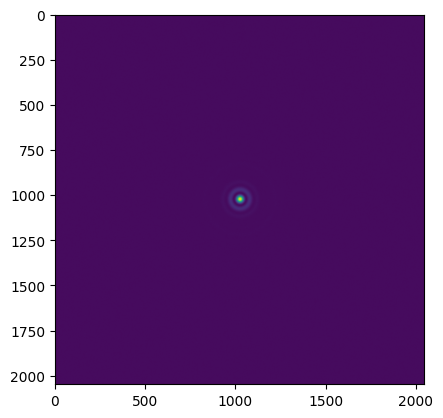

In [15]:
plt.imshow(test_empirical_2d)
plt.show()

In [ ]:
# generate the best-fit model based on the fit parameters

initial_guess_model_1d = model_for_fit(r_rad_2d, D_aperture_fit, D_obscuration_fit, ampl_fit).reshape(baseline_shape)
best_fit_model_1d = model_for_fit(r_rad_2d, D_aperture_fit, D_obscuration_fit, ampl_fit).reshape(baseline_shape)

# Calculate chi-squared
chi_squared = np.sum((test_empirical_1d - best_fit_model_1d.flatten())**2 / (0.01**2))  # assuming noise std = 0.01
dof = len(test_empirical_1d) - 3  # degrees of freedom (data points - number of parameters)
reduced_chi_squared = chi_squared / dof

# reshape the best fit into the same shape as the empirical data
best_fit_model_2d = best_fit_model_1d.reshape(baseline_shape)

print(f"\nChi-squared = {chi_squared:.2f}")
print(f"Degrees of freedom = {dof}")
print(f"Reduced chi-squared = {reduced_chi_squared:.6f}")


Chi-squared = 4193032.02
Degrees of freedom = 4194301
Reduced chi-squared = 0.999697


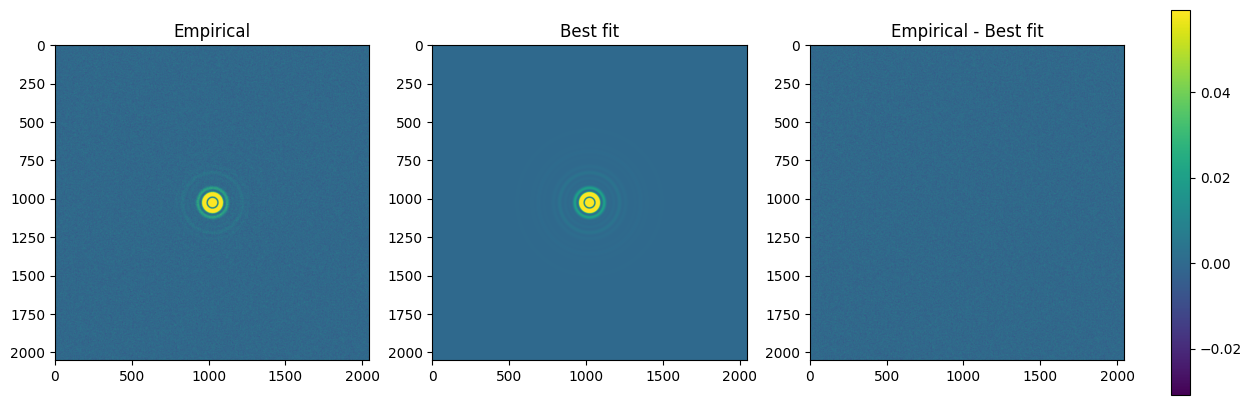

In [ ]:
zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(test_empirical_2d)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Empirical data
im0 = axs[0].imshow(test_empirical_2d, vmin=vmin, vmax=vmax)
axs[0].set_title("Empirical")

# Panel 2: Best fit
im1 = axs[1].imshow(best_fit_model_2d, vmin=vmin, vmax=vmax)
axs[1].set_title("Best fit")

# Panel 3: Residuals
im2 = axs[2].imshow(test_empirical_2d - best_fit_model_2d, vmin=vmin, vmax=vmax)
axs[2].set_title("Empirical - Best fit")

# Add one colorbar for all
fig.colorbar(im0, ax=axs, orientation='vertical', fraction=0.04, pad=0.04)

plt.show()